In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

Since all the libraries are imported, we start working on the project
#Credit Scoring Model

In [30]:
df = pd.read_csv('train.csv.zip')

df.head()

/tmp/ipykernel_1052/1496331631.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('train.csv.zip')


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [31]:
df.shape

(100000, 28)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [33]:
df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [34]:
df.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,15002
Num_Bank_Accounts,0


In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
drop_cols = ['ID','Customer_ID','Name','SSN','Month']

df.drop(columns=drop_cols, inplace=True)

df.head()

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,23,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,-500,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,23,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


Need to clean some dirty values like underscores

In [37]:
for col in df.columns:
    df[col] = df[col].astype(str).str.replace('_','', regex=False)

In [38]:
df.replace(['', 'nan'], np.nan, inplace=True)

In [39]:
numeric_cols = [
'Age',
'Annual_Income',
'Monthly_Inhand_Salary',
'Num_Bank_Accounts',
'Num_Credit_Card',
'Interest_Rate',
'Num_of_Loan',
'Delay_from_due_date',
'Num_of_Delayed_Payment',
'Changed_Credit_Limit',
'Num_Credit_Inquiries',
'Outstanding_Debt',
'Credit_Utilization_Ratio',
'Total_EMI_per_month',
'Amount_invested_monthly',
'Monthly_Balance'
]

In [40]:
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [41]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [42]:
df.isnull().sum()

,0
Age,0
Occupation,7062
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Type_of_Loan,11408
Delay_from_due_date,0


null values in categorical columns.. lets try to remove them too

In [43]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [44]:
df.isnull().sum()

,0
Age,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Type_of_Loan,0
Delay_from_due_date,0


yes thats perfect we removed all the null values out of the datset and replaced with their mean or mode

In [45]:
encoder = LabelEncoder()

categorical = [
'Occupation',
'Type_of_Loan',
'Credit_Mix',
'Payment_of_Min_Amount',
'Payment_Behaviour',
'Credit_History_Age'
]

for col in categorical:
    df[col] = encoder.fit_transform(df[col])

In [46]:
print(df.shape)

(100000, 23)


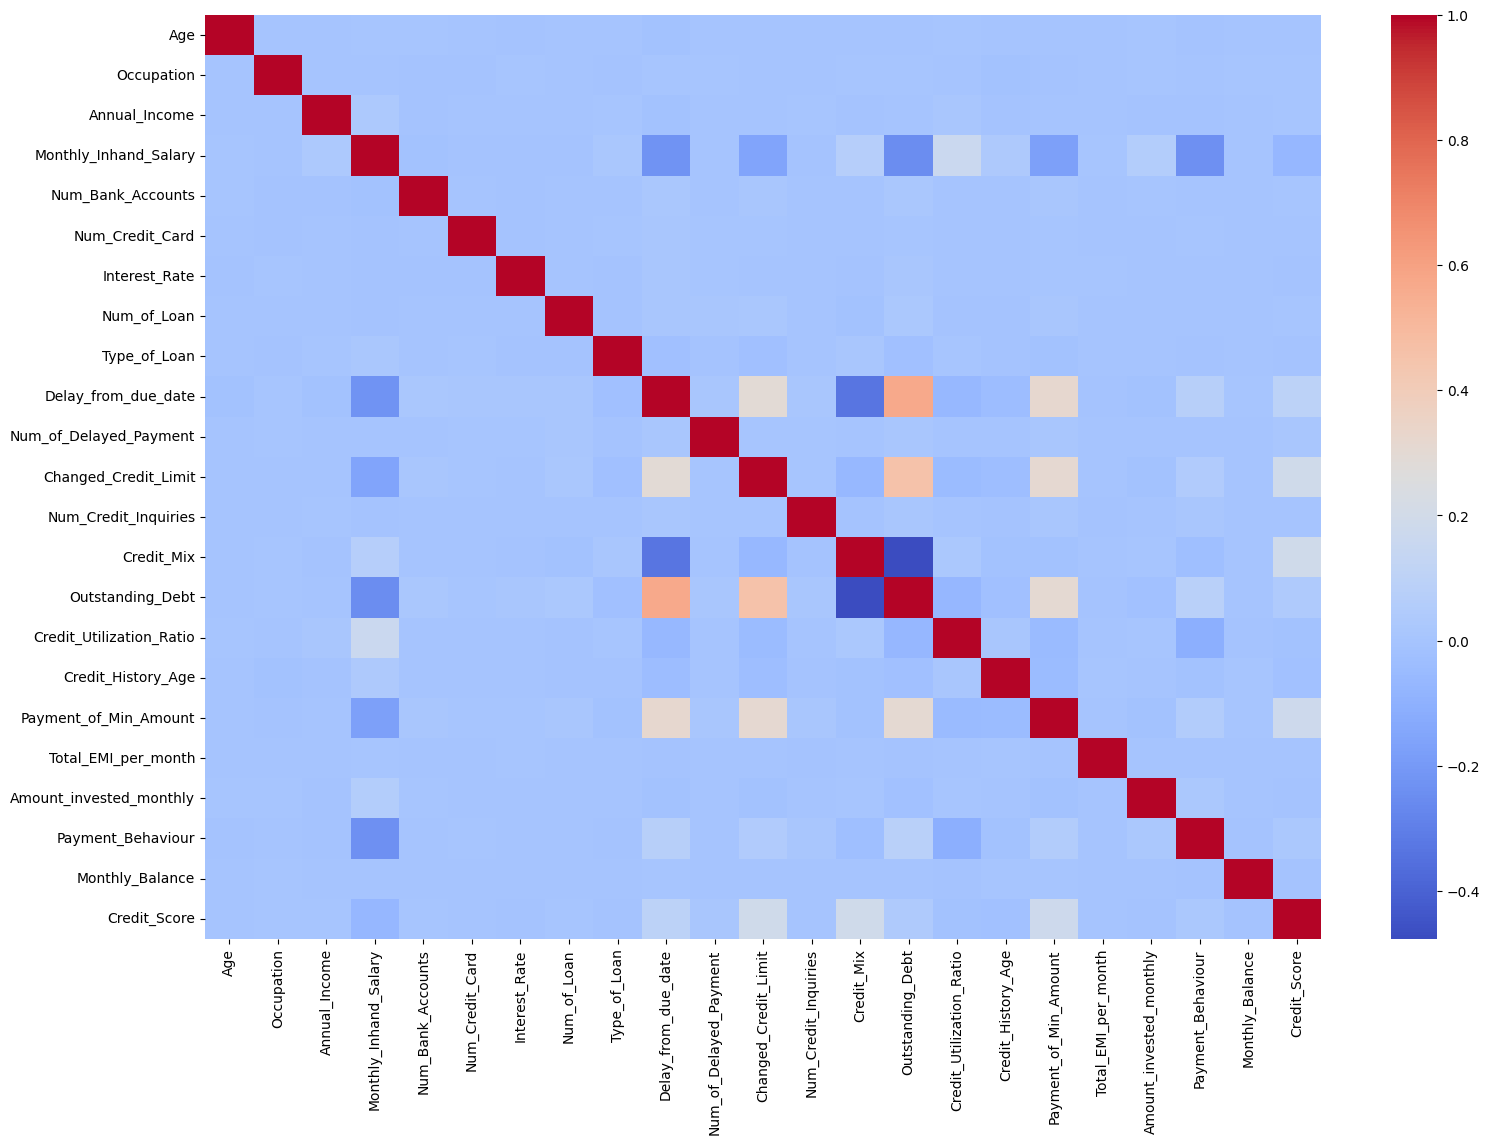

In [48]:
encoder = LabelEncoder()
df['Credit_Score'] = encoder.fit_transform(df['Credit_Score'])

plt.figure(figsize=(18,12))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [49]:
df.columns

Index(['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

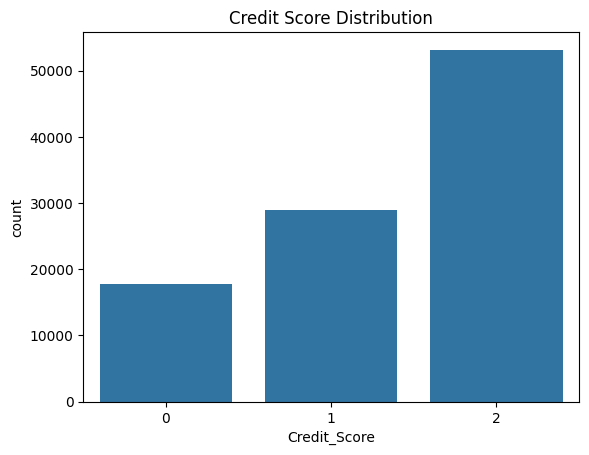

In [50]:
sns.countplot(x='Credit_Score', data=df)
plt.title("Credit Score Distribution")
plt.show()

0-poor

1-standard

2-good

In [51]:
X = df.drop('Credit_Score', axis=1)

y = df['Credit_Score']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

#Train the model
1. Random forest
2. Logistic regression
3. Decision tree

In [54]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [55]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [56]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [57]:
pred_lr = lr.predict(X_test)

pred_dt = dt.predict(X_test)

pred_rf = rf.predict(X_test)

#Evaluation function

In [58]:
def evaluate(model_name, y_test, pred):

    print("="*50)
    print(model_name)

    print("Accuracy :", accuracy_score(y_test,pred))

    print("Precision :", precision_score(y_test,pred,average='weighted'))

    print("Recall :", recall_score(y_test,pred,average='weighted'))

    print("F1 Score :", f1_score(y_test,pred,average='weighted'))

    print("\nClassification Report\n")
    print(classification_report(y_test,pred))

    print("\nConfusion Matrix\n")
    print(confusion_matrix(y_test,pred))

In [59]:
evaluate("Logistic Regression", y_test, pred_lr)

evaluate("Decision Tree", y_test, pred_dt)

evaluate("Random Forest", y_test, pred_rf)

Logistic Regression
Accuracy : 0.6077
Precision : 0.6055359382496707
Recall : 0.6077
F1 Score : 0.5936058629618032

Classification Report

              precision    recall  f1-score   support

           0       0.53      0.39      0.45      3527
           1       0.64      0.43      0.51      5874
           2       0.62      0.78      0.69     10599

    accuracy                           0.61     20000
   macro avg       0.59      0.53      0.55     20000
weighted avg       0.61      0.61      0.59     20000


Confusion Matrix

[[1372   50 2105]
 [ 298 2508 3068]
 [ 935 1390 8274]]
Decision Tree
Accuracy : 0.69025
Precision : 0.6901302991753473
Recall : 0.69025
F1 Score : 0.690156701939622

Classification Report

              precision    recall  f1-score   support

           0       0.60      0.60      0.60      3527
           1       0.69      0.67      0.68      5874
           2       0.72      0.73      0.73     10599

    accuracy                           0.69     20000


Random Forest achieved more accuracy compared to three so we use this model for further feature and prediction making

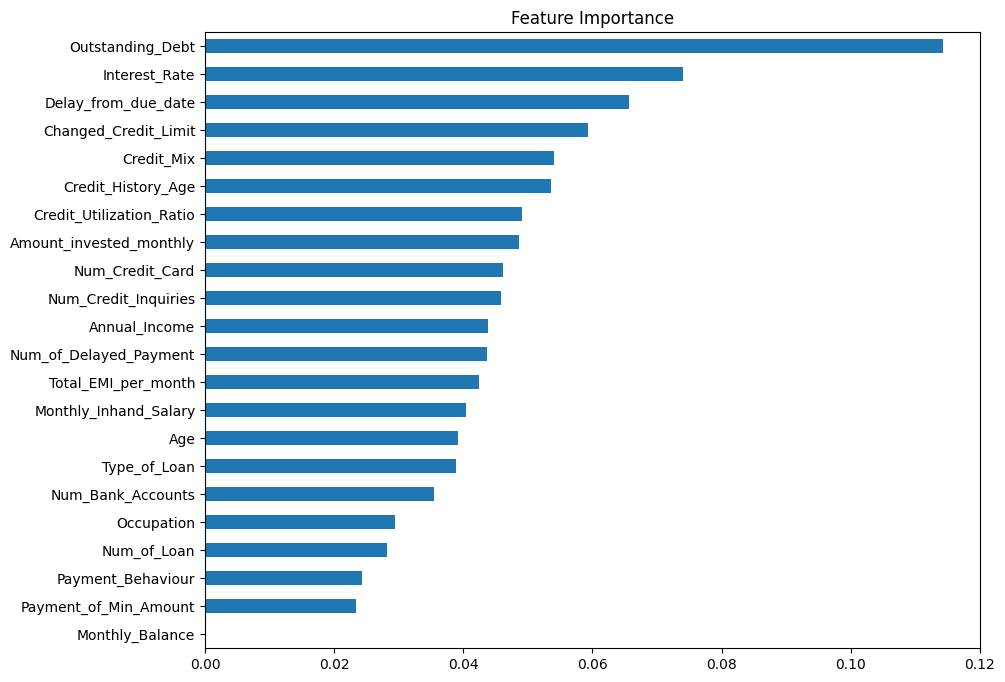

In [60]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance = importance.sort_values()

plt.figure(figsize=(10,8))
importance.plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [62]:
sample = X.iloc[[100]]

sample_scaled = scaler.transform(sample)

prediction = rf.predict(sample_scaled)

print("Predicted Credit Score:", prediction)

Predicted Credit Score: [2]


In [64]:
from sklearn.metrics import roc_auc_score

y_score = rf.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test,
    y_score,
    multi_class='ovr'
)

print("Overall ROC-AUC Score:", roc_auc)

Overall ROC-AUC Score: 0.9124144025092833


Successfully cleaned and preprocessed the credit scoring dataset.

Performed exploratory data analysis to understand customer financial behavior.

Trained Logistic Regression, Decision Tree, and Random Forest classifiers.

Compared models using Accuracy, Precision, Recall, and F1-Score.

Random Forest achieved the best performance and was selected as the final model for predicting customer credit scores.